# Phase-2b Lyα P1D emulator — Notebook 1: how to train

This notebook walks through **training** the deployed Phase-2b emulator
from the production cache, using the *production API* directly
(`hcd_analysis.emulator.{data,train,model}`) — no logic is reimplemented
here. It trains a **short, illustrative fold-0** so the whole notebook runs
in a couple of minutes on CPU; the production recipe runs ~150–250 epochs
across **8 LOSO folds** (see the closing section).

**Companion:** `02_emulator_plotting.ipynb` loads the *finalized* checkpoints
and produces the full performance walkthrough.

---
## 1. Architecture (what we are training)

The emulator (`hcd_analysis.emulator.model.Emulator`) is a shared **encoder**
feeding three heads. Its central design move is a **baseline + residual**
split of the per-class filtered P1D, `P_filt`:

- **θ-blind baseline** `m̂(z, τ₀)` — a deep MLP (`BaselineHead`) that sees
  *only* `(z, τ₀)`, never the 9 cosmology/IGM params. It predicts the
  `(z,τ₀)`-conditional **mean** spectrum (the dominant ~99.5% of the per-k
  log-variance). Because θ never enters, `∂m̂/∂θ = 0` exactly.
- **cosmology residual** `r̂(θ, z, τ₀)` — `HeadB` predicts the per-k
  **σ_cosmo-whitened residual** (the ~0.4% cosmology signal). Full log-P1D is
  `logP̂ = (m̂·σ_marg + μ_marg) + σ_cosmo·r̂`, so `∂logP̂/∂θ = σ_cosmo·∂r̂/∂θ`.
- **per-k conditional σ_cosmo whitening** — the residual target is whitened
  per `(class,k)` by `σ_cosmo` = the within-cell cosmology scale, so the
  residual head learns a ~unit-variance signal.
- **SVD basis + differentiable spline** — both P_filt paths decode through a
  low-rank, SVD-warm-started learned basis (`n_basis=24`); the residual is a
  smooth, differentiable function of k (HMC-usable downstream).
- **Head A** — `dN/dX` + CDDF (`f_nhi`); τ₀-invariant (reads only the latent).
- **single-α_c HCD** — the 3 HCD-class `Δ_c` templates re-weight the
  structural total `P_tier_p = Σ_c w_c·P_filt`.
- **MF (ρ-only + res_corr)** — the multi-fidelity LF→HF layer
  (`hcd_analysis.emulator.multifidelity`); covered at the end + in NB 2.

## 2. The `FINAL_RECIPE` knobs

The production recipe lives in `scripts/run_loso_sweep.py::FINAL_RECIPE`. The
load-bearing knobs (and *why* each exists):

- **deep frozen pre-fit baseline** — the θ-blind baseline is *pre-fit* to its
  `(z,τ₀)`-cell-mean floor (`prefit_baseline_epochs`), then **frozen** during
  the joint loop so it cannot drift off that floor (the joint early-stop, driven
  by the larger residual term, would otherwise cut it off too early).
- **weighted-mean loss** — `masked_mse` normalizes by `Σ(weight·mask)`, not the
  raw count, so per-class `inv_nc` weights set *relative* attention without
  globally shrinking the gradient scale.
- **`w_coh` coherent de-bias** (=80) — a FLAT-in-k regularizer on the per-cell
  θ-mean of the residual error; flattens the coherent low-k tilt the per-sim
  MSE leaves free (drives gate failures 3/8→1/8).
- **edge k-weight** (`edge_gain=3`, `lowk_extra=2`) — U-shaped per-k emphasis on
  the band edges (low-k is where A_p pivots).
- **data-range soft down-weight** — out-of-range bins (z∉[2.2,4.6] or k<1e-3)
  get ~0.2× weight, focusing capacity on the modes DESI constrains.
- **`term_w[p_resid]=8`** — up-weights the cosmology term (uniform default would
  dilute it 1:5).
- **early-stop on resid+coh** — the inference-relevant metric.

In [1]:
# The `emu-jax` kernelspec sets CPU-only JAX + PYTHONNOUSERSITE.
import os, sys
from pathlib import Path
# Portable repo-root detection (no hardcoded user path): honor HCD_PRIYA_ROOT,
# else walk up from the CWD to the dir that contains the hcd_analysis package.
ROOT = Path(os.environ.get('HCD_PRIYA_ROOT', '')).expanduser()
if not (ROOT / 'hcd_analysis').is_dir():
    ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'hcd_analysis').is_dir()), Path.cwd())
os.chdir(ROOT)                       # so relative repo paths resolve
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))    # so 'import hcd_analysis' works for any kernel
print('repo root:', ROOT)
import time, json
import numpy as np
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp

# importing the package enables jax_enable_x64 (the structural identities need it)
import hcd_analysis.emulator  # noqa: F401
from hcd_analysis.emulator.data import (
    load_cache, make_splits, make_batch, reconstruct_P_filt, safe_log,
    cell_id, edge_emphasis_k_weight, datarange_mask, COARSE_NAMES, DATA_RANGE,
)
from hcd_analysis.emulator.train import train_fold, load_checkpoint, save_checkpoint
from hcd_analysis.emulator.model import Emulator
from scripts.run_loso_sweep import FINAL_RECIPE

print('jax devices:', jax.devices())
print('x64 enabled:', jax.config.jax_enable_x64)
print('FINAL_RECIPE:', FINAL_RECIPE)

repo root: /home/mfho/hcd_priya


jax devices: [CpuDevice(id=0)]
x64 enabled: True
FINAL_RECIPE: {'n_basis': 24, 'p_resid_w': 8.0, 'edge_gain': 3.0, 'lowk_extra': 2.0, 'w_coh': 80.0, 'weight_decay': 0.0003, 'datarange': True, 'epochs': 180, 'patience': 25, 'lr': 0.001, 'batch': 512}


## 3. Load the production LF cache

`load_cache` reads the v3.3 HDF5 cache, collapses the 15 fine HCD classes to 4
coarse ones (`clean, LLS, subDLA, DLA`), builds the τ₀ coordinate, the
unit-cube encoder input `x = [params_unit(9), z_unit(1)]`, the analytic
`inv_nc` sample-variance weights, and the Nyquist masks.

In [2]:
LF_CACHE = str(ROOT / 'hcd_analysis/_emulator_data/observables_tau0_lf.h5')
t0 = time.time()
d = load_cache(LF_CACHE)
n_k = d['P_tier_p'].shape[1]
kf = d['kfkms'][0]               # shared k-grid (s/km)
print(f'loaded in {time.time()-t0:.1f}s')
print(f"rows={d['P_tier_p'].shape[0]}  n_k={n_k}  "
      f"sims={len(set(d['sim_name']))}  classes={COARSE_NAMES}")
print('k range [s/km]:', f'{kf.min():.2e} .. {kf.max():.2e}')
print('z grid:', np.unique(np.round(d['z_grid'], 2)))
print('key cache contents (shape):')
for key in ['x', 'tau0', 'P_filt', 'delta', 'snap_dNdX', 'snap_f_nhi',
            'inv_nc', 'w_c_cache', 'mask']:
    print(f'  {key:14s} {np.asarray(d[key]).shape}')

loaded in 3.7s
rows=21440  n_k=172  sims=60  classes=('clean', 'LLS', 'subDLA', 'DLA')
k range [s/km]: 4.04e-04 .. 6.94e-02
z grid: [2.  2.2 2.4 2.6 2.8 3.  3.2 3.4 3.6 3.8 4.  4.2 4.4 4.6 4.8 5.  5.2 5.4]
key cache contents (shape):
  x              (21440, 10)
  tau0           (21440,)
  P_filt         (21440, 4, 172)
  delta          (21440, 3, 172)
  snap_dNdX      (1072, 3)
  snap_f_nhi     (1072, 30)
  inv_nc         (21440, 4)
  w_c_cache      (21440, 4)
  mask           (21440, 172)


### LOSO split for fold 0

`make_splits` composes a **τ₀-edge holdout** (the extrapolation probe, excluded
from both train and val) with a **leave-one-sim-out** (LOSO) partition. Fold 0
holds out a disjoint group of *sims* for validation — so val accuracy measures
generalization to **unseen cosmologies**.

In [3]:
FOLD = 0
train_idx, val_idx, holdout_idx = make_splits(d, FOLD, n_folds=8, holdout_frac=0.15)
print(f'fold {FOLD}:  train={len(train_idx)}  val={len(val_idx)}  '
      f'holdout={len(holdout_idx)} (τ₀-edge, unseen)')
val_sims = sorted(set(d['sim_name'][val_idx]))
train_sims = sorted(set(d['sim_name'][train_idx]))
print(f'held-out val sims ({len(val_sims)}):', val_sims)
assert not (set(val_sims) & set(train_sims)), 'LOSO: val sims must be disjoint from train'
print('LOSO no-straddle: OK (val sims disjoint from train)')

fold 0:  train=15796  val=2428  holdout=3216 (τ₀-edge, unseen)
held-out val sims (8): [np.str_('ns0.803Ap2.2e-09herei4.05heref2.67alphaq2.21hub0.735omegamh20.141hireionz7.17bhfeedback0.056'), np.str_('ns0.813Ap2.51e-09herei3.84heref3.02alphaq1.66hub0.68omegamh20.14hireionz7.35bhfeedback0.0326'), np.str_('ns0.816Ap1.55e-09herei3.55heref3.15alphaq1.48hub0.658omegamh20.143hireionz7.38bhfeedback0.0533'), np.str_('ns0.816Ap2.58e-09herei3.73heref2.69alphaq2.16hub0.732omegamh20.143hireionz7.97bhfeedback0.0587'), np.str_('ns0.81Ap1.6e-09herei3.59heref2.79alphaq1.71hub0.668omegamh20.145hireionz7.92bhfeedback0.0333'), np.str_('ns0.81Ap2.54e-09herei4.29heref2.91alphaq2.65hub0.746omegamh20.144hireionz7.56bhfeedback0.0483'), np.str_('ns0.823Ap1.92e-09herei3.79heref3.09alphaq1.8hub0.685omegamh20.144hireionz7.08bhfeedback0.0667'), np.str_('ns0.829Ap2.39e-09herei3.63heref2.97alphaq1.61hub0.698omegamh20.143hireionz6.78bhfeedback0.044')]
LOSO no-straddle: OK (val sims disjoint from train)


## 4. Train a short, illustrative fold-0

> **Illustrative only.** We run ~35 epochs with a reduced baseline pre-fit
> (~2000 steps) to keep the notebook to a couple of minutes. **Production uses
> ~150–250 epochs over all 8 LOSO folds** with `prefit_baseline_epochs=8000`
> (the default in `train_fold`).

We feed `train_fold` the `FINAL_RECIPE` knobs verbatim: the edge k-weight, the
`p_resid` up-weight via `term_w`, the FLAT coherent de-bias `w_coh`, the
data-range down-weight, weight decay, and `n_basis=24` (SVD-warm-started).

In [4]:
# Build the FINAL_RECIPE knobs the train_fold call consumes.
k_weight = edge_emphasis_k_weight(
    kf, edge_gain=FINAL_RECIPE['edge_gain'], lowk_extra=FINAL_RECIPE['lowk_extra'])
term_w = {'f_nhi': 1.0, 'dndx': 1.0, 'p_base': 1.0,
          'p_resid': FINAL_RECIPE['p_resid_w'], 'delta': 1.0}

# notebook-scale overrides (clearly illustrative; production = the comments)
NB_EPOCHS = 35          # production: 180 (FINAL_RECIPE['epochs'])
NB_PREFIT = 2000        # production: 8000 (train_fold default)

t0 = time.time()
model, norm_stats, history = train_fold(
    d, train_idx, val_idx,
    n_basis=FINAL_RECIPE['n_basis'], lr=FINAL_RECIPE['lr'],
    epochs=NB_EPOCHS, batch_size=FINAL_RECIPE['batch'], seed=0,
    key=jax.random.PRNGKey(0), patience=FINAL_RECIPE['patience'], n_k=n_k,
    term_w=term_w, k_weight=k_weight, w_coh=FINAL_RECIPE['w_coh'],
    datarange=FINAL_RECIPE['datarange'], weight_decay=FINAL_RECIPE['weight_decay'],
    prefit_baseline_epochs=NB_PREFIT,
)
n_ep = len(history['train_loss'])
print(f'trained {n_ep} epochs in {time.time()-t0:.1f}s '
      f'(includes the {NB_PREFIT}-step baseline pre-fit)')

trained 35 epochs in 74.0s (includes the 2000-step baseline pre-fit)


### Train / val loss curves

**How to read:** the joint train (solid) and val (dashed) loss should both fall
and plateau; the val **residual** loss (the cosmology term, dotted) is the
inference-relevant early-stop metric. The vertical line marks the restored-best
epoch. The baseline is *pre-fit then frozen*, so the joint loop is mostly
training the θ-dependent residual + Head A.

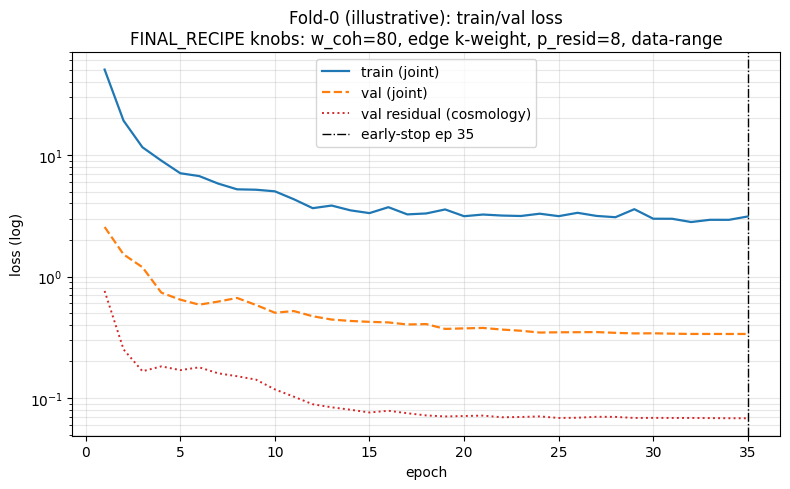

In [5]:
ep = np.arange(1, len(history['train_loss']) + 1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(ep, history['train_loss'], '-', color='C0', lw=1.6, label='train (joint)')
ax.semilogy(ep, history['val_loss'], '--', color='C1', lw=1.6, label='val (joint)')
vr = np.asarray(history['val_resid_loss'])
if np.isfinite(vr).any():
    ax.semilogy(ep, vr, ':', color='C3', lw=1.4, label='val residual (cosmology)')
# early-stop (restore-best): argmin of resid+coh when coh present, else resid
vc = np.asarray(history['val_coh_loss'])
metric = vr + vc if np.isfinite(vc).all() and vc.size else vr
es = int(np.nanargmin(metric)) + 1 if np.isfinite(metric).any() else n_ep
ax.axvline(es, color='k', ls='-.', lw=1.0, label=f'early-stop ep {es}')
ax.set_xlabel('epoch'); ax.set_ylabel('loss (log)')
ax.set_title('Fold-0 (illustrative): train/val loss\n'
             'FINAL_RECIPE knobs: w_coh=80, edge k-weight, p_resid=8, data-range')
ax.legend(); ax.grid(alpha=0.3, which='both')
fig.tight_layout(); plt.show()

## 5. Headline numbers for this short fold-0

Three honest, inference-relevant diagnostics, reusing the *same logic* as the
keeper diagnostics (`plot_performance_walkthrough._honest_decomp` and
`diag_ap_fisher_bias.fisher_bias`):

1. **honest θ-tracking corr** — correlation between the *true* and *predicted*
   log-P1D deviation from the deployed baseline `m̂` (the cosmology signal). 1.0
   = perfect tracking of the cosmology-driven departure.
2. **deployed median |frac err|** (in-range) — `|P̂/P − 1|` over held-out rows,
   restricted to the DESI data range.
3. **A_p / n_s Fisher-bias quick-check** — the in-range deployed bias in σ units
   (the inference gate is |bias| < 0.2σ).

In [6]:
# 1) honest θ-tracking corr (logic from plot_performance_walkthrough._honest_decomp)
pf = norm_stats['P_filt']
sig_marg, mu_marg, sig_cosmo = pf['sig_marg'], pf['mu_marg'], pf['sig_cosmo']
b = make_batch(d, val_idx, norm_stats)
pred = jax.vmap(model)(jnp.asarray(b['x']), jnp.asarray(b['tau0']))
base = np.asarray(pred['P_filt_base']); resid = np.asarray(pred['P_filt_resid'])
m_hat = base * sig_marg + mu_marg                 # deployed baseline logP
lt = safe_log(d['P_filt'][val_idx])               # true logP
lp = m_hat + sig_cosmo * resid                    # deployed pred logP
dev_t = (lt - m_hat).ravel(); dev_p = (lp - m_hat).ravel()
g = np.isfinite(dev_t) & np.isfinite(dev_p)
theta_corr = float(np.corrcoef(dev_t[g], dev_p[g])[0, 1])

# 2) deployed median |frac err| in the DESI data range
P_pred = reconstruct_P_filt(base, resid, pf)
P_true = d['P_filt'][val_idx]
mk = d['mask'][val_idx]; ir = datarange_mask(d)[val_idx]
keep = (np.isfinite(P_pred) & np.isfinite(P_true) & (P_true > 0)
        & mk[:, None, :] & ir[:, None, :])
with np.errstate(invalid='ignore', divide='ignore'):
    frac = np.abs(P_pred / P_true - 1.0)
frac = np.where(keep, frac, np.nan)
median_frac = float(np.nanmedian(frac))

print(f'honest θ-tracking corr        : {theta_corr:.3f}  (1.0 = perfect)')
print(f'deployed median |frac err|    : {median_frac*100:.2f}%  (in-range, held-out)')

honest θ-tracking corr        : 0.974  (1.0 = perfect)
deployed median |frac err|    : 1.17%  (in-range, held-out)


In [7]:
# 3) A_p / n_s Fisher-bias quick-check — port of diag_ap_fisher_bias.fisher_bias
#    (9-param Fisher at the z=3 fiducial slice, in-range modes, σ units).
PARAM_NAMES = ['ns', 'Ap', 'herei', 'heref', 'alphaq',
               'hub', 'omegamh2', 'hireionz', 'bhfeedback']
SIGMA_FRAC = {'clean': 0.03, 'LLS': 0.15, 'subDLA': 0.15, 'DLA': 0.15}  # DESI-DR1-like
sc = pf['sig_cosmo']
z_grid = d['z_grid']
zsel = np.isclose(z_grid, 3.0, atol=0.05)
tau0_fid = float(np.median(d['tau0'][zsel]))
z_unit_fid = float(np.median(d['x'][zsel, 9]))
vz = np.isclose(d['z_grid'][val_idx], 3.0, atol=0.05)
mask_va = np.isfinite(safe_log(d['P_filt'][val_idx]))
kvalid = (mask_va[vz].mean(0) > 0.5)
z_j = jnp.asarray(z_unit_fid)

def _rhat(theta9):
    x = jnp.concatenate([theta9, z_j[None]])
    return model(x, jnp.asarray(tau0_fid))['P_filt_resid']
p0 = jnp.asarray(np.full(9, 0.5), dtype=jnp.float64)
Jr = np.asarray(jax.jacfwd(_rhat)(p0))            # (4,n_k,9)
J_logP = Jr * sc[:, :, None]

x_va = jnp.asarray(d['x'][val_idx][vz]); tau_va = jnp.asarray(d['tau0'][val_idx][vz])
prv = jax.vmap(model)(x_va, tau_va)
bb = np.asarray(prv['P_filt_base']) * pf['sig_marg'] + pf['mu_marg']
logP_hat = bb + sc * np.asarray(prv['P_filt_resid'])
logP_true = safe_log(d['P_filt'][val_idx][vz]); ms = np.isfinite(logP_true)
with np.errstate(invalid='ignore'):
    delta = np.array([[np.nanmean(np.where(ms[:, ci, j],
                       (logP_hat - logP_true)[:, ci, j], np.nan))
                       for j in range(n_k)] for ci in range(4)])
rJ, rd, rC = [], [], []
for ci, nm in enumerate(COARSE_NAMES):
    for j in range(n_k):
        if (not kvalid[ci, j] or not np.all(np.isfinite(J_logP[ci, j]))
                or not np.isfinite(delta[ci, j])):
            continue
        rJ.append(J_logP[ci, j]); rd.append(delta[ci, j]); rC.append(SIGMA_FRAC[nm] ** 2)
J9 = np.array(rJ); dv = np.array(rd); Cinv = 1.0 / np.array(rC)
F = (J9.T * Cinv) @ J9
ridge = 1e-12 * np.trace(F) / 9.0
Finv = np.linalg.inv(F + ridge * np.eye(9))
sigma = np.sqrt(np.diag(Finv))
bias = (Finv @ ((J9.T * Cinv) @ dv)) / sigma
bias_d = {PARAM_NAMES[i]: float(bias[i]) for i in range(9)}
print(f"Fisher-bias A_p : {bias_d['Ap']:+.3f} σ   (gate |bias|<0.2σ)")
print(f"Fisher-bias n_s : {bias_d['ns']:+.3f} σ")
print(f'(over {len(dv)} in-range modes at z=3)')

Fisher-bias A_p : +0.083 σ   (gate |bias|<0.2σ)
Fisher-bias n_s : -0.004 σ
(over 688 in-range modes at z=3)


> **Note (illustrative caveat).** These come from a short ~35-epoch single-fold
> run; the *finalized* 8-fold checkpoints (loaded in NB 2) report the production
> numbers. The point here is that the recipe trains a sensible model fast: even
> this short fold tracks the cosmology signal well and stays inside the Fisher
> gate.

## 6. Save / load a checkpoint

`save_checkpoint` writes three files: `.eqx` (the Equinox leaves), `.meta.json`
(arch config completed from the model's static fields, the git SHA, the k-grid,
and the FINAL_RECIPE), and `.norm.pkl` (the train-split normalization). The
checkpoint is **self-describing** — `load_checkpoint` rebuilds the exact model.

In [8]:
ckpt = str(ROOT / 'checkpoints/walkthrough_nb_fold0')
recipe = dict(
    n_basis=FINAL_RECIPE['n_basis'], p_resid_w=FINAL_RECIPE['p_resid_w'],
    edge_gain=FINAL_RECIPE['edge_gain'], lowk_extra=FINAL_RECIPE['lowk_extra'],
    w_coh=FINAL_RECIPE['w_coh'], weight_decay=FINAL_RECIPE['weight_decay'],
    datarange=FINAL_RECIPE['datarange'], epochs=NB_EPOCHS, term_w=term_w,
    note='illustrative short notebook fold-0; NOT a production checkpoint')
save_checkpoint(ckpt, model, {'in_dim': 10, 'n_k': n_k, 'n_basis': FINAL_RECIPE['n_basis']},
                norm_stats, seed=0, kfkms=d['kfkms'], cache_path=LF_CACHE, recipe=recipe)
print('wrote', ckpt + '.{eqx,meta.json,norm.pkl}')

# round-trip: load_checkpoint rebuilds the model + meta + norm
m2, meta2, norm2 = load_checkpoint(ckpt)
print('reloaded arch_cfg:', meta2['arch_cfg'])
print('reloaded git_sha :', meta2.get('git_sha'))
# verify the reloaded model gives identical predictions on a few rows
chk = val_idx[:8]
p_a = jax.vmap(model)(jnp.asarray(d['x'][chk]), jnp.asarray(d['tau0'][chk]))['P_filt_resid']
p_b = jax.vmap(m2)(jnp.asarray(d['x'][chk]), jnp.asarray(d['tau0'][chk]))['P_filt_resid']
print('round-trip max |Δ residual|:', float(np.max(np.abs(np.asarray(p_a) - np.asarray(p_b)))))

wrote /home/mfho/hcd_priya/checkpoints/walkthrough_nb_fold0.{eqx,meta.json,norm.pkl}


reloaded arch_cfg: {'in_dim': 10, 'n_k': 172, 'n_basis': 24, 'baseline_n_layers': 3, 'baseline_width': 256}
reloaded git_sha : a349a41


round-trip max |Δ residual|: 0.0


## 7. The full 8-fold LOSO sweep + the multi-fidelity layer

**Full LOSO sweep (production).** `scripts/run_loso_sweep.py` runs the recipe
above across all 8 LOSO folds, saving `checkpoints/final_fold{0..7}.{eqx,...}`,
the per-epoch histories, and the aggregated **error vector** (`error_vector.npz`,
RMS-over-folds fractional P1D σ + DLA high-k shot-noise flag) that feeds the
likelihood covariance. To reproduce:

```bash
PYTHONNOUSERSITE=1 PYTHONPATH="$PWD" \   # run from the repo root
  /home/mfho/.conda/envs/emu-jax/bin/python3 scripts/run_loso_sweep.py
#   add --smoke for a fast 2-fold / few-epoch end-to-end check
```

**Multi-fidelity (LF→HF).** The frozen LF backbone (these checkpoints) is the
input to the resolution-correction layer in
`hcd_analysis.emulator.multifidelity`. The forward model is
`P_MF = (ρ(k,z) · f_LF) · res_corr`, with the validated default head being
ρ(k,z)-only (`FixedMeanHead`, no learned θ-correction — the learned-MLP head
over-fits the θ-gradient on the 6 HF sims). Build it via:

```python
from hcd_analysis.emulator import multifidelity as MF
lf_model, meta, lf_norm, lf_logk = MF.load_lf_backbone(fold=0)
# measure targets, build the default head, then MF.build_multifidelity(...)
# end-to-end driver: scripts/build_mf_delta.py
```

NB 2 shows the MF high-k performance figure (B6).